# **Generative Modelling Case Study**

**Module**: Advanced Research Topics – 7PAM2016

**Student**: Marati SiriVennela

**Tutor**(s): Sophie Koudmani & William Alston

**Coursework** Weighting: 40%

**Submission** Deadline: 23 April 2026

## Aim of this notebook
This notebook contains the implementation and evaluation of Generative Adversarial Networks (GANs) for:
1. Synthetic 2D data generation
2. Blood cell image generation using BloodMNIST
3. Synthetic network traffic generation using CICIDS 2017
4. Pizza sketch generation using QuickDraw

# 1. Setup
# 2. Part 1 – Building and Understanding GANs from Scratch
## 2.1 Sine-wave GAN
## 2.2 New 2D Distribution
## 2.3 Architecture Modification and Comparison

# 3. Part 2.1 – Blood Cell Microscope Imaging with BloodMNIST
## 3.1 Data Loading and Exploration
## 3.2 DCGAN Architecture
## 3.3 Training
## 3.4 Results and Evaluation

# 4. Part 2.2 – Cybersecurity: Synthetic Traffic with CICIDS 2017
## 4.1 Data Loading and Preprocessing
## 4.2 GAN for Tabular Data
## 4.3 Training
## 4.4 PCA or t-SNE Comparison

# 5. Part 2.3 – Creative AI: QuickDraw Pizza
## 5.1 Data Loading and Exploration
## 5.2 DCGAN Architecture
## 5.3 Training
## 5.4 Results and Evaluation

# 6. Conclusion

## **Python libraries**

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.10.0+cpu
Using device: cpu


## **Install Packages**

In [2]:
!pip install medmnist -q
!pip install torchmetrics -q
!pip install torchvision -q
!pip install scikit-learn -q
!pip install tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 34.1 MB/s eta 0:00:00


# **Part 1 – 2.1 Building and Understanding GANs from Scratch**
## 2.1 Sine‑wave GAN

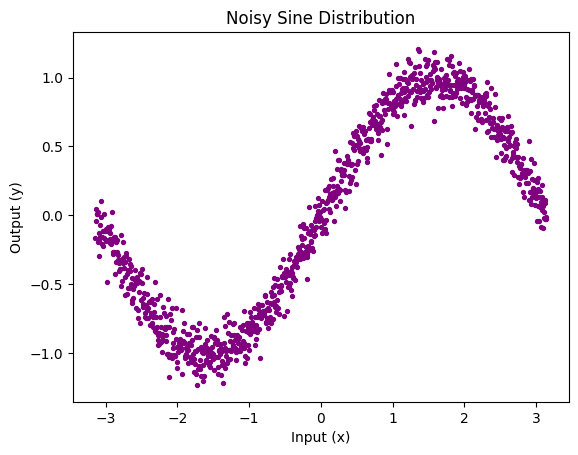

In [3]:
# 2.1 Sine-wave GAN

import numpy as np
import torch
import matplotlib.pyplot as plt

# Function to create noisy sine arc points
def create_sine_points(num_samples=1024):
    x_coordinates = np.linspace(-np.pi, np.pi, num_samples)
    y_coordinates = np.sin(x_coordinates) + 0.1 * np.random.randn(num_samples)
    combined_points = np.vstack((x_coordinates, y_coordinates)).T
    return torch.tensor(combined_points, dtype=torch.float32)

# generate dataset and visualization
sine_dataset = create_sine_points()

plt.scatter(sine_dataset[:, 0], sine_dataset[:, 1], s=8, color='purple')
plt.title("Noisy Sine Distribution")
plt.xlabel("Input (x)")
plt.ylabel("Output (y)")
plt.show()


##2.1 Define Generator

In [4]:
# 2.1 Generator Network

import torch.nn as nn

class SinePointGenerator(nn.Module):
    def __init__(self, input_size=2, hidden_size=64, output_size=2):
        super().__init__()
        self.generator_stack = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_size, hidden_size),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, noise_batch):
        return self.generator_stack(noise_batch)

##2.1 Discriminator

In [5]:
# 2.1 Discriminator Network

class SinePointDiscriminator(nn.Module):
    def __init__(self, input_size=2, hidden_size=64):
        super().__init__()
        self.discriminator_stack = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_size, hidden_size),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_size, 1),
            nn.Sigmoid()
        )

    def forward(self, point_batch):
        return self.discriminator_stack(point_batch)

##2.1 Initialise Models, Loss, and Optimisers

In [6]:
# 2.1 Model Setup

sine_generator = SinePointGenerator().to(device)
sine_discriminator = SinePointDiscriminator().to(device)

adversarial_loss = nn.BCELoss()

generator_optimizer = torch.optim.Adam(sine_generator.parameters(), lr=0.001)
discriminator_optimizer = torch.optim.Adam(sine_discriminator.parameters(), lr=0.001)

latent_dimension = 2
mini_batch_size = 128
training_epochs = 3000

##2.1 Training Loop

In [7]:
# 2.1 Training Loop

generator_loss_history = []
discriminator_loss_history = []

for epoch_index in range(training_epochs):

    # draw a random batch from the real sine dataset
    sampled_indices = np.random.randint(0, sine_dataset.shape[0], mini_batch_size)
    real_samples = sine_dataset[sampled_indices].to(device)

    # create synthetic samples from random noise
    latent_noise = torch.randn(mini_batch_size, latent_dimension).to(device)
    generated_samples = sine_generator(latent_noise)

    # assign labels for real and fake samples
    real_targets = torch.ones(mini_batch_size, 1).to(device)
    fake_targets = torch.zeros(mini_batch_size, 1).to(device)

    # update discriminator using real and generated data
    discriminator_real_output = sine_discriminator(real_samples)
    discriminator_fake_output = sine_discriminator(generated_samples.detach())

    discriminator_loss = adversarial_loss(discriminator_real_output, real_targets) + \
                         adversarial_loss(discriminator_fake_output, fake_targets)

    discriminator_optimizer.zero_grad()
    discriminator_loss.backward()
    discriminator_optimizer.step()

    # update generator to fool the discriminator
    latent_noise = torch.randn(mini_batch_size, latent_dimension).to(device)
    generated_samples = sine_generator(latent_noise)

    generator_output = sine_discriminator(generated_samples)
    generator_loss = adversarial_loss(generator_output, real_targets)

    generator_optimizer.zero_grad()
    generator_loss.backward()
    generator_optimizer.step()

    generator_loss_history.append(generator_loss.item())
    discriminator_loss_history.append(discriminator_loss.item())

    if epoch_index % 500 == 0:
        print(
            f"Epoch {epoch_index}/{training_epochs} | "
            f"D Loss: {discriminator_loss.item():.4f} | "
            f"G Loss: {generator_loss.item():.4f}"
        )

Epoch 0/3000 | D Loss: 1.3753 | G Loss: 0.6850
Epoch 500/3000 | D Loss: 1.3823 | G Loss: 0.7166
Epoch 1000/3000 | D Loss: 1.3570 | G Loss: 0.8291
Epoch 1500/3000 | D Loss: 1.3959 | G Loss: 0.6830
Epoch 2000/3000 | D Loss: 1.3842 | G Loss: 0.7090
Epoch 2500/3000 | D Loss: 1.3666 | G Loss: 0.7448


##2.1 Visualise Training Loss

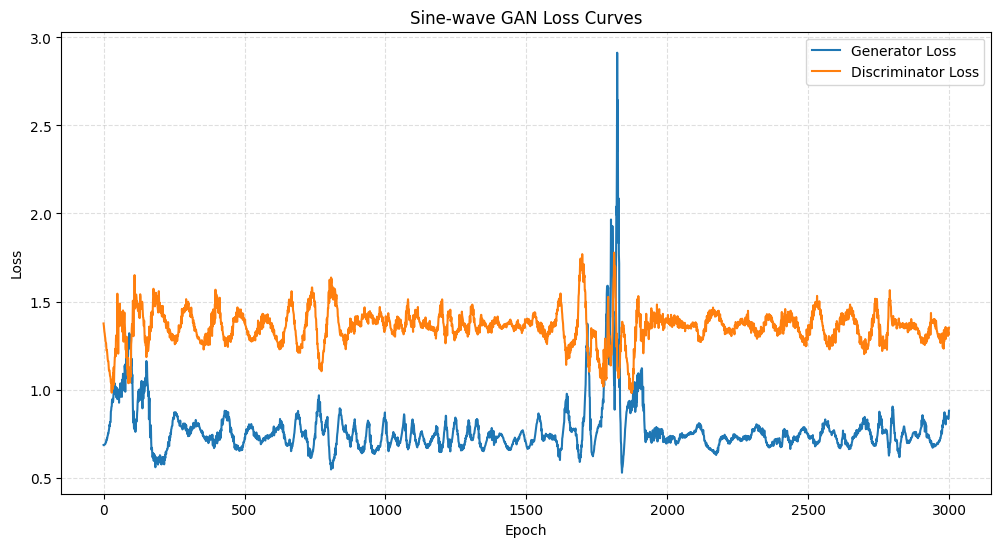

In [8]:
# 2.1 Training Loss Plot

plt.figure(figsize=(12, 6))
plt.plot(generator_loss_history, label="Generator Loss")
plt.plot(discriminator_loss_history, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Sine-wave GAN Loss Curves")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

## 2.1 compare Generate vs real plots

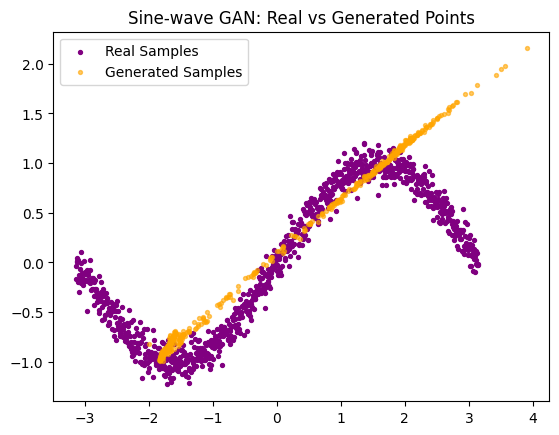

In [9]:
# 2.1 Compare Real and Generated Samples

with torch.no_grad():
    latent_noise = torch.randn(512, latent_dimension).to(device)
    generated_points = sine_generator(latent_noise).cpu()

plt.scatter(sine_dataset[:, 0], sine_dataset[:, 1], s=8, color="purple", label="Real Samples")
plt.scatter(generated_points[:, 0], generated_points[:, 1], s=8, color="orange", alpha=0.6, label="Generated Samples")
plt.title("Sine-wave GAN: Real vs Generated Points")
plt.legend()
plt.show()

# **PART **2.2** — New 2D Distribution**

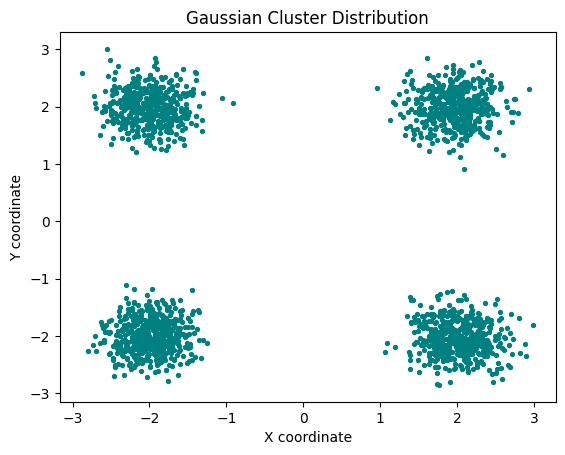

In [10]:
# 2.2 Generate Gaussian Cluster Dataset

def create_cluster_points(total_samples=2000):
    cluster_locations = [(-2, -2), (2, 2), (-2, 2), (2, -2)]
    collected_points = []

    for center_x, center_y in cluster_locations:
        x_coordinates = np.random.normal(loc=center_x, scale=0.3, size=total_samples // 4)
        y_coordinates = np.random.normal(loc=center_y, scale=0.3, size=total_samples // 4)

        cluster_points = np.column_stack((x_coordinates, y_coordinates))
        collected_points.append(cluster_points)

    merged_points = np.vstack(collected_points)
    return torch.tensor(merged_points, dtype=torch.float32)

gaussian_dataset = create_cluster_points()

plt.scatter(gaussian_dataset[:, 0], gaussian_dataset[:, 1], s=8, color="teal")
plt.title("Gaussian Cluster Distribution")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.show()

##2.2Define Generator and Discriminator


In [11]:
# 2.2 Define Generator and Discriminator

class GaussianPointGenerator(nn.Module):
    def __init__(self, latent_size=2, hidden_units=64):
        super().__init__()
        self.generator_layers = nn.Sequential(
            nn.Linear(latent_size, hidden_units),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_units, hidden_units),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_units, 2)
        )

    def forward(self, noise_batch):
        return self.generator_layers(noise_batch)


class GaussianPointDiscriminator(nn.Module):
    def __init__(self, input_size=2, hidden_units=64):
        super().__init__()
        self.discriminator_layers = nn.Sequential(
            nn.Linear(input_size, hidden_units),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_units, hidden_units),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_units, 1),
            nn.Sigmoid()
        )

    def forward(self, point_batch):
        return self.discriminator_layers(point_batch)

## 2.2 model setup

In [12]:
# 2.2 Model Setup

gaussian_generator = GaussianPointGenerator().to(device)
gaussian_discriminator = GaussianPointDiscriminator().to(device)

gaussian_loss = nn.BCELoss()

gaussian_gen_optimizer = optim.Adam(gaussian_generator.parameters(), lr=0.001)
gaussian_disc_optimizer = optim.Adam(gaussian_discriminator.parameters(), lr=0.001)

gaussian_latent_size = 2
gaussian_batch_size = 128
gaussian_epochs = 3000

## 2.2 Training Loop

In [13]:
# 2.2 Training Loop

gaussian_gen_history = []
gaussian_disc_history = []

for epoch_index in range(gaussian_epochs):

    chosen_indices = np.random.randint(0, gaussian_dataset.shape[0], gaussian_batch_size)
    real_cluster_batch = gaussian_dataset[chosen_indices].to(device)

    latent_noise = torch.randn(gaussian_batch_size, gaussian_latent_size).to(device)
    generated_cluster_batch = gaussian_generator(latent_noise)

    real_targets = torch.ones(gaussian_batch_size, 1).to(device)
    fake_targets = torch.zeros(gaussian_batch_size, 1).to(device)

    # update discriminator with real and generated clusters
    real_scores = gaussian_discriminator(real_cluster_batch)
    fake_scores = gaussian_discriminator(generated_cluster_batch.detach())

    discriminator_loss = gaussian_loss(real_scores, real_targets) + \
                         gaussian_loss(fake_scores, fake_targets)

    gaussian_disc_optimizer.zero_grad()
    discriminator_loss.backward()
    gaussian_disc_optimizer.step()

    # update generator to create more realistic cluster points
    latent_noise = torch.randn(gaussian_batch_size, gaussian_latent_size).to(device)
    generated_cluster_batch = gaussian_generator(latent_noise)

    generator_loss = gaussian_loss(
        gaussian_discriminator(generated_cluster_batch),
        real_targets
    )

    gaussian_gen_optimizer.zero_grad()
    generator_loss.backward()
    gaussian_gen_optimizer.step()

    gaussian_gen_history.append(generator_loss.item())
    gaussian_disc_history.append(discriminator_loss.item())

    if epoch_index % 500 == 0:
        print(
            f"Epoch {epoch_index}/{gaussian_epochs} | "
            f"D Loss: {discriminator_loss.item():.4f} | "
            f"G Loss: {generator_loss.item():.4f}"
        )

Epoch 0/3000 | D Loss: 1.4503 | G Loss: 0.7172
Epoch 500/3000 | D Loss: 1.3504 | G Loss: 1.0574
Epoch 1000/3000 | D Loss: 1.0157 | G Loss: 1.2479
Epoch 1500/3000 | D Loss: 1.0569 | G Loss: 1.2730
Epoch 2000/3000 | D Loss: 0.9841 | G Loss: 1.2570
Epoch 2500/3000 | D Loss: 0.9739 | G Loss: 0.9764


##2.2 Compare Real and Generated Samples

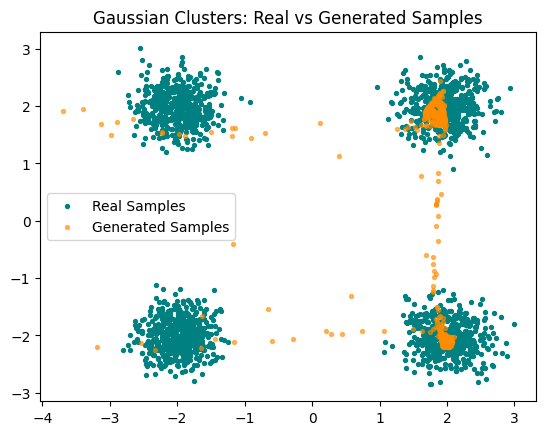

In [14]:
# 2.2 Compare Real and Generated Samples

with torch.no_grad():
    latent_noise = torch.randn(512, gaussian_latent_size).to(device)
    generated_cluster_points = gaussian_generator(latent_noise).cpu()

plt.scatter(gaussian_dataset[:, 0], gaussian_dataset[:, 1], s=8, color="teal", label="Real Samples")
plt.scatter(generated_cluster_points[:, 0], generated_cluster_points[:, 1], s=8, color="darkorange", alpha=0.6, label="Generated Samples")
plt.title("Gaussian Clusters: Real vs Generated Samples")
plt.legend()
plt.show()

# **PART 2.3 — Architecture Modification & Comparison**

## 2.3 Define Enhanced Generator

In [15]:
# 2.3 Define Enhanced Generator

class RefinedPointGenerator(nn.Module):
    def __init__(self, latent_size=2):
        super().__init__()

        self.refined_generator = nn.Sequential(
            nn.Linear(latent_size, 128),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(128),

            nn.Linear(128, 128),
            nn.ReLU(inplace=True),

            nn.Linear(128, 64),
            nn.ReLU(inplace=True),

            nn.Linear(64, 2)
        )

    def forward(self, latent_batch):
        return self.refined_generator(latent_batch)

## 2.3 Define Enhanced Discriminator

In [16]:
# 2.3 Define Enhanced Discriminator

class RefinedPointDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.refined_discriminator = nn.Sequential(
            nn.Linear(2, 128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(128, 64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(64, 32),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, sample_batch):
        return self.refined_discriminator(sample_batch)

## 2.3 Model Setup

In [17]:
# 2.3 Model Setup

refined_generator = RefinedPointGenerator().to(device)
refined_discriminator = RefinedPointDiscriminator().to(device)

refined_loss = nn.BCELoss()

refined_gen_optimizer = optim.Adam(refined_generator.parameters(), lr=0.0008)
refined_disc_optimizer = optim.Adam(refined_discriminator.parameters(), lr=0.0008)

refined_gen_losses = []
refined_disc_losses = []

## 2.3 Training Loop

In [18]:
# 2.3 Training Loop

for epoch_index in range(3000):

    sampled_indices = np.random.randint(0, gaussian_dataset.shape[0], gaussian_batch_size)
    real_sample_batch = gaussian_dataset[sampled_indices].to(device)

    latent_noise = torch.randn(gaussian_batch_size, gaussian_latent_size).to(device)
    synthetic_batch = refined_generator(latent_noise)

    real_targets = torch.ones(gaussian_batch_size, 1).to(device)
    fake_targets = torch.zeros(gaussian_batch_size, 1).to(device)

    # update refined discriminator
    real_predictions = refined_discriminator(real_sample_batch)
    fake_predictions = refined_discriminator(synthetic_batch.detach())

    discriminator_loss = refined_loss(real_predictions, real_targets) + \
                         refined_loss(fake_predictions, fake_targets)

    refined_disc_optimizer.zero_grad()
    discriminator_loss.backward()
    refined_disc_optimizer.step()

    # update refined generator
    latent_noise = torch.randn(gaussian_batch_size, gaussian_latent_size).to(device)
    synthetic_batch = refined_generator(latent_noise)

    generator_loss = refined_loss(
        refined_discriminator(synthetic_batch),
        real_targets
    )

    refined_gen_optimizer.zero_grad()
    generator_loss.backward()
    refined_gen_optimizer.step()

    refined_gen_losses.append(generator_loss.item())
    refined_disc_losses.append(discriminator_loss.item())

    if epoch_index % 500 == 0:
        print(
            f"Epoch {epoch_index}/3000 | "
            f"D Loss: {discriminator_loss.item():.4f} | "
            f"G Loss: {generator_loss.item():.4f}"
        )

Epoch 0/3000 | D Loss: 1.3494 | G Loss: 0.6605
Epoch 500/3000 | D Loss: 1.7370 | G Loss: 1.1022
Epoch 1000/3000 | D Loss: 1.3345 | G Loss: 0.7418
Epoch 1500/3000 | D Loss: 1.3633 | G Loss: 0.9098
Epoch 2000/3000 | D Loss: 1.2187 | G Loss: 0.7440
Epoch 2500/3000 | D Loss: 1.1425 | G Loss: 0.8357


## 2.3 Generate Enhanced Samples

In [19]:
# 2.3 Generate Enhanced Samples

with torch.no_grad():
    latent_noise = torch.randn(512, gaussian_latent_size).to(device)
    refined_samples = refined_generator(latent_noise).cpu()

## 2.3 Compare Original and Modified Outputs

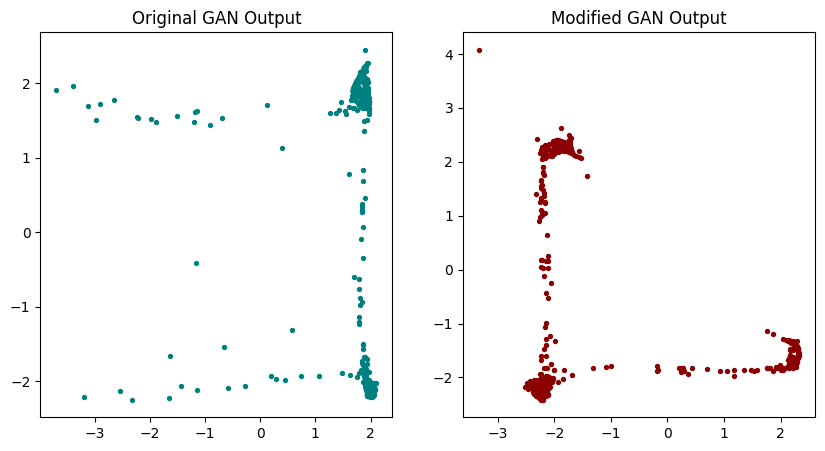

In [20]:
# 2.3 Compare Original and Modified Outputs

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(generated_cluster_points[:, 0], generated_cluster_points[:, 1], s=8, color="teal")
plt.title("Original GAN Output")

plt.subplot(1, 2, 2)
plt.scatter(refined_samples[:, 0], refined_samples[:, 1], s=8, color="darkred")
plt.title("Modified GAN Output")

plt.show()

#

# **3. Part 2.1 – Blood Cell Microscope Imaging with BloodMNIST**

## 3.1 Data Loading & Exploration

In [21]:
# 3.1 Load BloodMNIST Dataset

from medmnist import BloodMNIST, INFO
from torchvision import transforms
from torch.utils.data import DataLoader

blood_flag = "bloodmnist"
blood_info = INFO[blood_flag]

blood_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

blood_dataset = BloodMNIST(
    split="train",
    transform=blood_transform,
    download=True
)

blood_loader = DataLoader(
    blood_dataset,
    batch_size=128,
    shuffle=True
)

100%|██████████| 35.5M/35.5M [00:01<00:00, 21.9MB/s]


## 3.1 Visualise Sample BloodMNIST Images

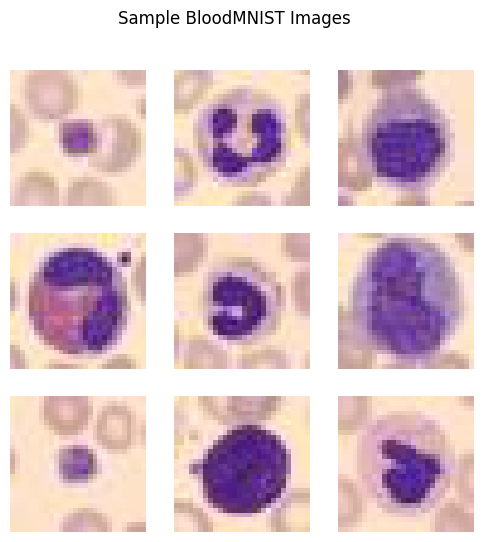

In [22]:
# 3.1 Visualise Sample BloodMNIST Images

blood_sample_images, _ = next(iter(blood_loader))
blood_display_images = (blood_sample_images * 0.5) + 0.5

plt.figure(figsize=(6, 6))
for image_index in range(9):
    plt.subplot(3, 3, image_index + 1)
    plt.imshow(blood_display_images[image_index].permute(1, 2, 0).clamp(0, 1))
    plt.axis("off")

plt.suptitle("Sample BloodMNIST Images")
plt.show()

## 3.2 Define Blood Image Generator

In [23]:
# 3.2 Define Blood Image Generator

class BloodImageGenerator(nn.Module):
    def __init__(self, latent_size=100):
        super().__init__()

        self.generator_layers = nn.Sequential(
            nn.ConvTranspose2d(latent_size, 256, kernel_size=7, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 3, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, latent_noise):
        reshaped_noise = latent_noise.view(latent_noise.size(0), latent_noise.size(1), 1, 1)
        return self.generator_layers(reshaped_noise)

## 3.2 Define Blood Image Discriminator

In [24]:
# 3.2 Define Blood Image Discriminator

class BloodImageDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.discriminator_layers = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, image_batch):
        return self.discriminator_layers(image_batch)

## 3.3 model Setup

In [25]:
# 3.3 Model Setup

blood_generator = BloodImageGenerator().to(device)
blood_discriminator = BloodImageDiscriminator().to(device)

blood_loss = nn.BCELoss()

blood_gen_optimizer = optim.Adam(blood_generator.parameters(), lr=0.0002)
blood_disc_optimizer = optim.Adam(blood_discriminator.parameters(), lr=0.0002)

blood_latent_size = 100
blood_epochs = 10
blood_batch_limit = 50

## 3.3 Training Loop

In [26]:
# 3.3 Training Loop

blood_gen_losses = []
blood_disc_losses = []

for epoch_index in range(blood_epochs):

    cumulative_generator_loss = 0.0
    cumulative_discriminator_loss = 0.0

    for batch_index, (real_blood_images, _) in enumerate(blood_loader):

        if batch_index >= blood_batch_limit:
            break

        real_blood_images = real_blood_images.to(device)
        current_batch_size = real_blood_images.size(0)

        real_targets = torch.ones(current_batch_size, 1).to(device)
        fake_targets = torch.zeros(current_batch_size, 1).to(device)

        # update discriminator using real and generated blood images
        latent_noise = torch.randn(current_batch_size, blood_latent_size, 1, 1).to(device)
        synthetic_blood_images = blood_generator(latent_noise)

        discriminator_loss = blood_loss(
            blood_discriminator(real_blood_images), real_targets
        ) + blood_loss(
            blood_discriminator(synthetic_blood_images.detach()), fake_targets
        )

        blood_disc_optimizer.zero_grad()
        discriminator_loss.backward()
        blood_disc_optimizer.step()

        # update generator so generated images look more realistic
        latent_noise = torch.randn(current_batch_size, blood_latent_size, 1, 1).to(device)
        synthetic_blood_images = blood_generator(latent_noise)

        generator_loss = blood_loss(
            blood_discriminator(synthetic_blood_images), real_targets
        )

        blood_gen_optimizer.zero_grad()
        generator_loss.backward()
        blood_gen_optimizer.step()

        cumulative_generator_loss += generator_loss.item()
        cumulative_discriminator_loss += discriminator_loss.item()

    average_generator_loss = cumulative_generator_loss / blood_batch_limit
    average_discriminator_loss = cumulative_discriminator_loss / blood_batch_limit

    blood_gen_losses.append(average_generator_loss)
    blood_disc_losses.append(average_discriminator_loss)

    print(
        f"Epoch {epoch_index + 1}/{blood_epochs} | "
        f"D Loss: {average_discriminator_loss:.4f} | "
        f"G Loss: {average_generator_loss:.4f}"
    )

Epoch 1/10 | D Loss: 0.5260 | G Loss: 2.3029
Epoch 2/10 | D Loss: 0.1171 | G Loss: 4.1039
Epoch 3/10 | D Loss: 0.0418 | G Loss: 5.2354
Epoch 4/10 | D Loss: 0.0547 | G Loss: 5.1427
Epoch 5/10 | D Loss: 0.0166 | G Loss: 5.4629
Epoch 6/10 | D Loss: 0.0165 | G Loss: 5.5948
Epoch 7/10 | D Loss: 0.0180 | G Loss: 5.8367
Epoch 8/10 | D Loss: 0.0140 | G Loss: 5.9471
Epoch 9/10 | D Loss: 0.0184 | G Loss: 6.0515
Epoch 10/10 | D Loss: 0.0265 | G Loss: 5.8437


## 3.4 Generate Fake Blood Images

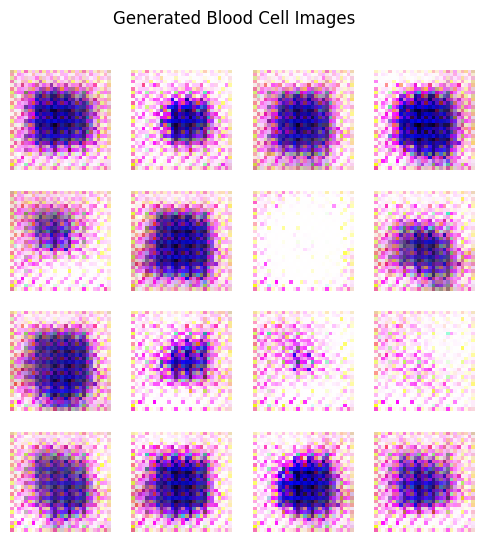

In [28]:
# 3.4 Generate Synthetic Blood Images

with torch.no_grad():
    latent_noise = torch.randn(16, blood_latent_size, 1, 1).to(device)
    generated_blood_images = blood_generator(latent_noise).cpu()

generated_blood_images = (generated_blood_images + 1) / 2

plt.figure(figsize=(6, 6))
for image_index in range(16):
    plt.subplot(4, 4, image_index + 1)
    plt.imshow(generated_blood_images[image_index].permute(1, 2, 0).clamp(0, 1))
    plt.axis("off")

plt.suptitle("Generated Blood Cell Images")
plt.show()

## 3.5 Loss Plot

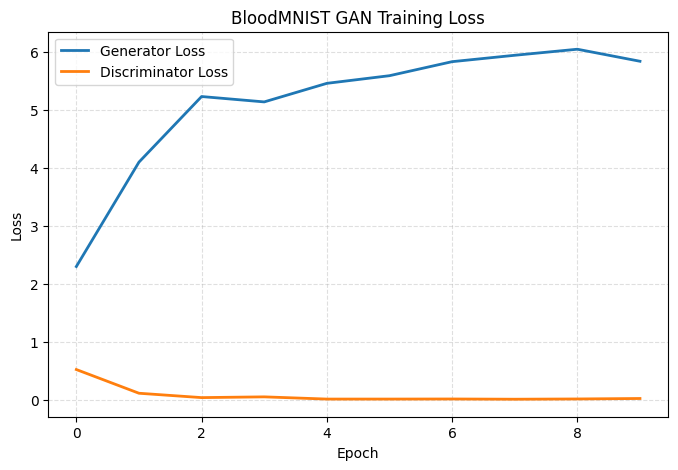

In [30]:
# 3.4 Plot BloodGAN Loss Curves

plt.figure(figsize=(8, 5))
plt.plot(blood_gen_losses, label="Generator Loss", linewidth=2)
plt.plot(blood_disc_losses, label="Discriminator Loss", linewidth=2)

plt.title("BloodMNIST GAN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

# **4. Part 2.2 – Cybersecurity: Synthetic Traffic with CICIDS 2017**

## 4. Part 2.2 – Cybersecurity: Synthetic Traffic with CICIDS 2017

## 4.1 Data Loading and preprocessing

In [31]:
# 4.1 Load Cyber Dataset

import pandas as pd

network_frame = pd.read_csv("Wednesday-workingHours.pcap_ISCX.csv")

print("Dataset shape:", network_frame.shape)
network_frame.head()

Dataset shape: (692703, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## 4.2 preprocessing

In [32]:
# 4.1 Clean and Prepare Network Traffic Data

import numpy as np
import torch
from sklearn.preprocessing import StandardScaler

# reload the raw file so this section always starts from clean data
network_frame = pd.read_csv("Wednesday-workingHours.pcap_ISCX.csv")

# remove extra spaces from column names
network_frame.columns = network_frame.columns.str.strip()

# ensure label column is text
network_frame["Label"] = network_frame["Label"].astype(str).str.strip()

print("Available label categories:")
print(network_frame["Label"].value_counts().head(10))

# keep only BENIGN and DoS-related traffic
network_frame = network_frame[
    network_frame["Label"].str.contains("BENIGN|DoS", case=False, na=False)
].copy()

print("\nLabels after filtering:")
print(network_frame["Label"].value_counts())

# convert labels into binary form
network_frame["Label"] = network_frame["Label"].apply(
    lambda entry: 0 if entry.upper() == "BENIGN" else 1
)

# separate features and targets
network_targets = network_frame["Label"].copy()
network_features = network_frame.drop(columns=["Label"]).copy()

# keep only numeric feature columns
network_features = network_features.select_dtypes(include=[np.number]).copy()

print("\nFeature shape before cleaning:", network_features.shape)

# handle infinite and missing values
network_features = network_features.replace([np.inf, -np.inf], np.nan)
network_features = network_features.fillna(network_features.median(numeric_only=True))
network_features = network_features.fillna(0)

print("Feature shape after cleaning:", network_features.shape)

# sample a smaller portion to speed up GAN training
sample_count = min(50000, len(network_features))
sampled_row_ids = network_features.sample(n=sample_count, random_state=42).index

network_features = network_features.loc[sampled_row_ids].reset_index(drop=True)
network_targets = network_targets.loc[sampled_row_ids].reset_index(drop=True)

print("Feature shape after sampling:", network_features.shape)
print("\nBinary label counts:")
print(network_targets.value_counts())

# standardize features
network_scaler = StandardScaler()
scaled_network_features = network_scaler.fit_transform(network_features)

# convert to tensor
network_tensor = torch.tensor(scaled_network_features, dtype=torch.float32)

print("\nFinal tensor shape:", network_tensor.shape)

Available label categories:
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64

Labels after filtering:
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Name: count, dtype: int64

Feature shape before cleaning: (692692, 78)
Feature shape after cleaning: (692692, 78)
Feature shape after sampling: (50000, 78)

Binary label counts:
Label
0    31900
1    18100
Name: count, dtype: int64

Final tensor shape: torch.Size([50000, 78])


## 4.2 Define Tabular Generator and Discriminator

In [33]:
# 4.2 Define Tabular Generator and Discriminator

class NetworkTrafficGenerator(nn.Module):
    def __init__(self, latent_size, output_size):
        super().__init__()

        self.generator_layers = nn.Sequential(
            nn.Linear(latent_size, 128),
            nn.ReLU(inplace=True),

            nn.Linear(128, 256),
            nn.ReLU(inplace=True),

            nn.Linear(256, output_size)
        )

    def forward(self, latent_noise):
        return self.generator_layers(latent_noise)


class NetworkTrafficDiscriminator(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.discriminator_layers = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, feature_batch):
        return self.discriminator_layers(feature_batch)

## 4.3 model setup

In [34]:
# 4.3 Model Setup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

network_latent_size = 32
network_feature_count = network_tensor.shape[1]

network_generator = NetworkTrafficGenerator(
    network_latent_size,
    network_feature_count
).to(device)

network_discriminator = NetworkTrafficDiscriminator(
    network_feature_count
).to(device)

network_loss = nn.BCELoss()

network_gen_optimizer = optim.Adam(network_generator.parameters(), lr=0.0005)
network_disc_optimizer = optim.Adam(network_discriminator.parameters(), lr=0.0005)

network_gen_losses = []
network_disc_losses = []

network_epochs = 500
network_batch_size = 128

## 4.3 Training Loop

In [35]:
# 4.3 Training Loop

for epoch_index in range(network_epochs):

    sampled_indices = np.random.randint(0, network_tensor.shape[0], network_batch_size)
    real_network_batch = network_tensor[sampled_indices].to(device)

    real_targets = torch.ones(network_batch_size, 1).to(device)
    fake_targets = torch.zeros(network_batch_size, 1).to(device)

    # update discriminator with real and synthetic traffic records
    latent_noise = torch.randn(network_batch_size, network_latent_size).to(device)
    generated_network_batch = network_generator(latent_noise)

    discriminator_real_loss = network_loss(
        network_discriminator(real_network_batch),
        real_targets
    )
    discriminator_fake_loss = network_loss(
        network_discriminator(generated_network_batch.detach()),
        fake_targets
    )
    discriminator_loss = discriminator_real_loss + discriminator_fake_loss

    network_disc_optimizer.zero_grad()
    discriminator_loss.backward()
    network_disc_optimizer.step()

    # update generator to produce more realistic traffic records
    latent_noise = torch.randn(network_batch_size, network_latent_size).to(device)
    generated_network_batch = network_generator(latent_noise)

    generator_loss = network_loss(
        network_discriminator(generated_network_batch),
        real_targets
    )

    network_gen_optimizer.zero_grad()
    generator_loss.backward()
    network_gen_optimizer.step()

    network_gen_losses.append(generator_loss.item())
    network_disc_losses.append(discriminator_loss.item())

    if epoch_index % 100 == 0:
        print(
            f"Epoch {epoch_index}/{network_epochs} | "
            f"D Loss: {discriminator_loss.item():.4f} | "
            f"G Loss: {generator_loss.item():.4f}"
        )

Epoch 0/500 | D Loss: 1.4126 | G Loss: 0.7377
Epoch 100/500 | D Loss: 0.6650 | G Loss: 2.3206
Epoch 200/500 | D Loss: 1.1026 | G Loss: 3.8676
Epoch 300/500 | D Loss: 0.5628 | G Loss: 2.4239
Epoch 400/500 | D Loss: 0.2429 | G Loss: 2.2947


## 4.4 PCA Comparison of Real and Generated Samples

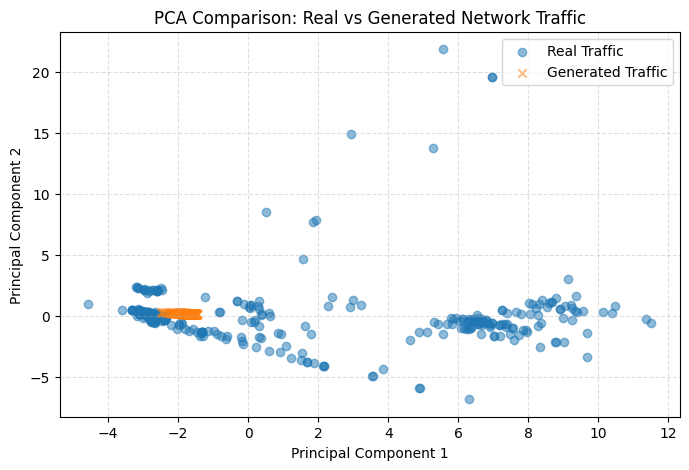

In [36]:
# 4.4 PCA Comparison of Real and Generated Samples

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

with torch.no_grad():
    latent_preview = torch.randn(500, network_latent_size).to(device)
    synthetic_network_vectors = network_generator(latent_preview).cpu().numpy()

real_network_vectors = scaled_network_features[:500]

pca_mapper = PCA(n_components=2)
real_projection = pca_mapper.fit_transform(real_network_vectors)
fake_projection = pca_mapper.transform(synthetic_network_vectors)

plt.figure(figsize=(8, 5))
plt.scatter(
    real_projection[:, 0],
    real_projection[:, 1],
    alpha=0.5,
    label="Real Traffic",
    marker="o"
)
plt.scatter(
    fake_projection[:, 0],
    fake_projection[:, 1],
    alpha=0.5,
    label="Generated Traffic",
    marker="x"
)

plt.title("PCA Comparison: Real vs Generated Network Traffic")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

## 4.4 Plot CyberGAN Loss Curves

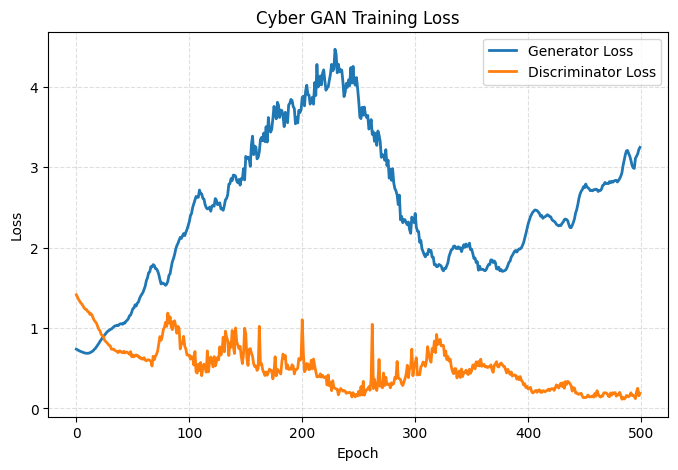

In [37]:
# 4.4 Plot CyberGAN Loss Curves

plt.figure(figsize=(8, 5))
plt.plot(network_gen_losses, label="Generator Loss", linewidth=2)
plt.plot(network_disc_losses, label="Discriminator Loss", linewidth=2)

plt.title("Cyber GAN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

# **Part 2.3 creative ai pizza**

## 5.1 Load Sketch Dataset

In [38]:
# 5.1 Load Sketch Dataset

import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

# load sketch array from file
pizza_sketch_array = np.load("pizza.npy")

# keep a smaller subset for quicker training
pizza_sketch_array = pizza_sketch_array[:5000]

# scale pixel values to [-1, 1]
pizza_sketch_array = (pizza_sketch_array.astype("float32") / 127.5) - 1.0

# reshape to image format
pizza_sketch_array = pizza_sketch_array.reshape(-1, 1, 28, 28)

# convert to tensor
pizza_sketch_tensor = torch.tensor(pizza_sketch_array)

# create dataset and loader
pizza_sketch_dataset = TensorDataset(pizza_sketch_tensor)
pizza_sketch_loader = DataLoader(pizza_sketch_dataset, batch_size=64, shuffle=True)

print("Loaded sketch tensor shape:", pizza_sketch_tensor.shape)
print("Pixel range:", pizza_sketch_tensor.min().item(), "to", pizza_sketch_tensor.max().item())

Loaded sketch tensor shape: torch.Size([5000, 1, 28, 28])
Pixel range: -1.0 to 1.0


## 5.1 Visualise Real Pizza Sketches

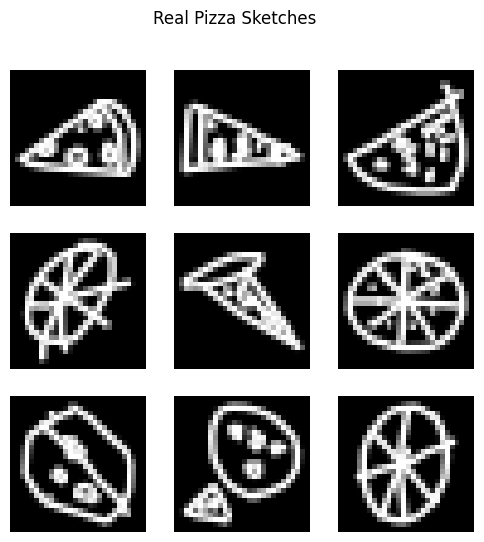

In [39]:
# 5.1 Visualise Real Pizza Sketches

preview_sketch_batch = (pizza_sketch_tensor[:9] + 1) / 2

plt.figure(figsize=(6, 6))
for preview_index in range(9):
    plt.subplot(3, 3, preview_index + 1)
    plt.imshow(preview_sketch_batch[preview_index][0], cmap="gray")
    plt.axis("off")

plt.suptitle("Real Pizza Sketches")
plt.show()

## 5.2 DCGAN

## 5.2 Define Sketch Generator

In [40]:
# 5.2 Define Sketch Generator

class PizzaSketchGenerator(nn.Module):
    def __init__(self, latent_size=100):
        super().__init__()

        self.generator_blocks = nn.Sequential(
            nn.ConvTranspose2d(latent_size, 128, kernel_size=7, stride=1, padding=0),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, latent_noise):
        return self.generator_blocks(latent_noise)

## 5.2 Define Sketch Discriminator

In [41]:
# 5.2 Define Sketch Discriminator

class PizzaSketchDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.discriminator_blocks = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, image_batch):
        return self.discriminator_blocks(image_batch)

## 5.3 Model Setup

In [42]:
# 5.3 Model Setup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pizza_generator_model = PizzaSketchGenerator().to(device)
pizza_discriminator_model = PizzaSketchDiscriminator().to(device)

pizza_gen_optimizer = optim.Adam(
    pizza_generator_model.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

pizza_disc_optimizer = optim.Adam(
    pizza_discriminator_model.parameters(),
    lr=0.0001,
    betas=(0.5, 0.999)
)

pizza_adversarial_loss = nn.BCELoss()

pizza_gen_loss_history = []
pizza_disc_loss_history = []

pizza_epochs = 8
pizza_batch_limit = 20
pizza_latent_size = 100

##5.3 training

In [43]:
# 5.3 Training Loop

for epoch_index in range(pizza_epochs):
    cumulative_gen_loss = 0.0
    cumulative_disc_loss = 0.0

    for batch_index, (real_sketch_batch,) in enumerate(pizza_sketch_loader):
        if batch_index >= pizza_batch_limit:
            break

        real_sketch_batch = real_sketch_batch.to(device)
        current_batch_size = real_sketch_batch.size(0)

        real_targets = torch.ones(current_batch_size, 1, device=device) * 0.9
        fake_targets = torch.zeros(current_batch_size, 1, device=device)

        # update discriminator with real and synthetic sketches
        latent_noise = torch.randn(current_batch_size, pizza_latent_size, 1, 1, device=device)
        generated_sketch_batch = pizza_generator_model(latent_noise)

        real_disc_loss = pizza_adversarial_loss(
            pizza_discriminator_model(real_sketch_batch),
            real_targets
        )
        fake_disc_loss = pizza_adversarial_loss(
            pizza_discriminator_model(generated_sketch_batch.detach()),
            fake_targets
        )
        discriminator_loss = real_disc_loss + fake_disc_loss

        pizza_disc_optimizer.zero_grad()
        discriminator_loss.backward()
        pizza_disc_optimizer.step()

        # update generator so generated sketches appear realistic
        latent_noise = torch.randn(current_batch_size, pizza_latent_size, 1, 1, device=device)
        generated_sketch_batch = pizza_generator_model(latent_noise)

        generator_loss = pizza_adversarial_loss(
            pizza_discriminator_model(generated_sketch_batch),
            real_targets
        )

        pizza_gen_optimizer.zero_grad()
        generator_loss.backward()
        pizza_gen_optimizer.step()

        cumulative_gen_loss += generator_loss.item()
        cumulative_disc_loss += discriminator_loss.item()

    average_gen_loss = cumulative_gen_loss / pizza_batch_limit
    average_disc_loss = cumulative_disc_loss / pizza_batch_limit

    pizza_gen_loss_history.append(average_gen_loss)
    pizza_disc_loss_history.append(average_disc_loss)

    print(
        f"Epoch {epoch_index + 1}/{pizza_epochs} | "
        f"D Loss: {average_disc_loss:.4f} | "
        f"G Loss: {average_gen_loss:.4f}"
    )

Epoch 1/8 | D Loss: 1.0512 | G Loss: 1.0671
Epoch 2/8 | D Loss: 0.8235 | G Loss: 1.4256
Epoch 3/8 | D Loss: 1.2433 | G Loss: 1.0607
Epoch 4/8 | D Loss: 1.3857 | G Loss: 0.9199
Epoch 5/8 | D Loss: 1.2821 | G Loss: 0.9401
Epoch 6/8 | D Loss: 1.1845 | G Loss: 0.9651
Epoch 7/8 | D Loss: 1.1408 | G Loss: 0.9918
Epoch 8/8 | D Loss: 1.1010 | G Loss: 1.0132


## 5.4 Generate Synthetic Pizza Sketches

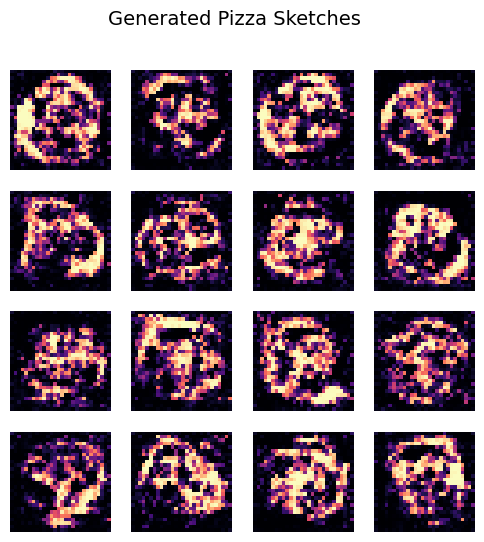

In [44]:
# 5.4 Generate Synthetic Pizza Sketches

with torch.no_grad():
    latent_noise = torch.randn(16, pizza_latent_size, 1, 1, device=device)
    generated_pizza_sketches = pizza_generator_model(latent_noise).cpu()

generated_pizza_sketches = (generated_pizza_sketches + 1) / 2

plt.figure(figsize=(6, 6))
for image_index in range(16):
    plt.subplot(4, 4, image_index + 1)
    plt.imshow(generated_pizza_sketches[image_index][0].clamp(0, 1), cmap="magma")
    plt.axis("off")

plt.suptitle("Generated Pizza Sketches", fontsize=14)
plt.show()

## 5.4 Plot PizzaGAN Loss Curves

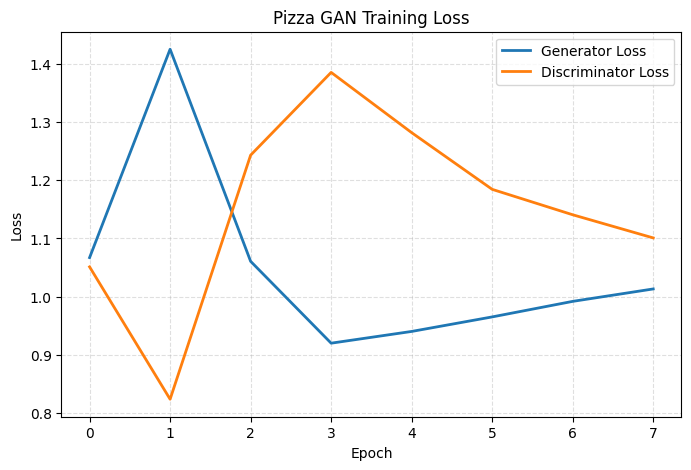

In [45]:
# 5.4 Plot PizzaGAN Loss Curves

plt.figure(figsize=(8, 5))
plt.plot(pizza_gen_loss_history, label="Generator Loss", linewidth=2)
plt.plot(pizza_disc_loss_history, label="Discriminator Loss", linewidth=2)

plt.title("Pizza GAN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()